In [2]:
import sys
import os

sys.path.append(os.path.abspath(".."))

In [3]:
from src.data_loader import load_conll

In [5]:
df = load_conll("../data/hinglish_train.txt")

In [6]:
df.head()

,tweet_id,sentiment,text
0,3,negative,@ AdilNisarButt pakistan ka ghra tauq he Pakis...
1,41,negative,Madarchod mulle ye mathura me Nahi dikha tha j...
2,48,positive,@ narendramodi Manya Pradhan Mantri mahoday Sh...
3,64,positive,@ Atheist _ Krishna Jcb full trend me chal rah...
4,66,positive,@ AbhisharSharma _ @ RavishKumarBlog Loksabha ...


In [7]:
df.shape

(15131, 3)

In [9]:
import matplotlib.pyplot as plt

In [10]:
sentiment_counts = df["sentiment"].value_counts()

print(sentiment_counts)

sentiment
neutral     5638
positive    5034
negative    4459
Name: count, dtype: int64


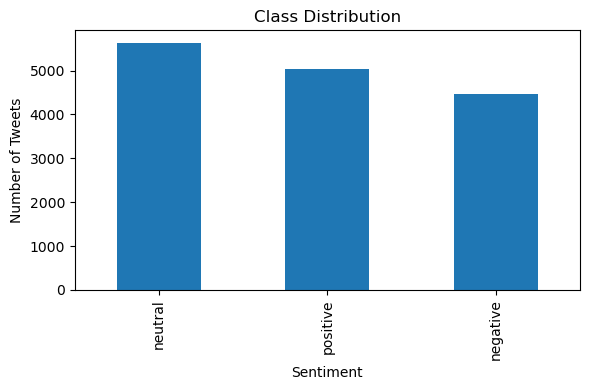

In [16]:
plt.figure(figsize=(6,4))

sentiment_counts.plot(kind="bar")

plt.title("Class Distribution")
plt.xlabel("Sentiment")
plt.ylabel("Number of Tweets")
plt.tight_layout()
plt.savefig("../results/class_distribution.png")
plt.show()

In [17]:
df["tweet_length"] = df["text"].apply(lambda x: len(x.split()))

In [18]:
df[["text", "tweet_length"]].head()

,text,tweet_length
0,@ AdilNisarButt pakistan ka ghra tauq he Pakis...,20
1,Madarchod mulle ye mathura me Nahi dikha tha j...,32
2,@ narendramodi Manya Pradhan Mantri mahoday Sh...,25
3,@ Atheist _ Krishna Jcb full trend me chal rah...,11
4,@ AbhisharSharma _ @ RavishKumarBlog Loksabha ...,32


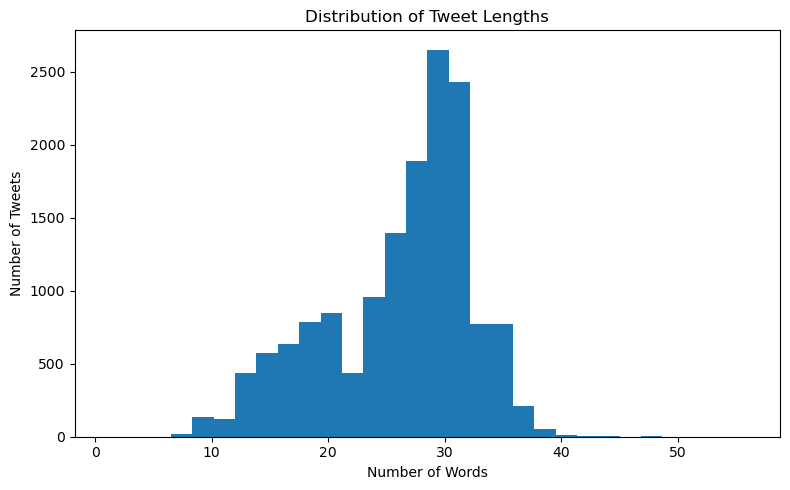

In [19]:
plt.figure(figsize=(8,5))

plt.hist(df["tweet_length"], bins=30)

plt.title("Distribution of Tweet Lengths")
plt.xlabel("Number of Words")
plt.ylabel("Number of Tweets")

plt.tight_layout()

plt.savefig("../results/tweet_length_distribution.png")

plt.show()

In [20]:
print("Average length:", df["tweet_length"].mean())
print("Median length:", df["tweet_length"].median())
print("Max length:", df["tweet_length"].max())
print("Min length:", df["tweet_length"].min())

Average length: 26.17262573524552
Median length: 28.0
Max length: 56
Min length: 1


In [21]:
with open("../data/hinglish_train.txt", "r", encoding="utf-8") as f:
    for _ in range(20):
        print(f.readline())

meta	3	negative

@	O

AdilNisarButt	Hin

pakistan	Hin

ka	Hin

ghra	Hin

tauq	Hin

he	Eng

Pakistan	Eng

Israel	Eng

ko	Eng

tasleem	Hin

nahein	Hin

kerta	Hin

Isko	Hin

Palestine	Hin

kehta	Hin

he	Hin

-	O

OCCUPIED	Hin



In [22]:
from collections import Counter

lang_counts = Counter()

In [23]:
with open("../data/hinglish_train.txt", "r", encoding="utf-8") as f:

    for line in f:

        line = line.strip()

        if not line:
            continue

        parts = line.split("\t")

        if parts[0] == "meta":
            continue

        if len(parts) >= 2:
            lang = parts[1]
            lang_counts[lang] += 1

In [24]:
print(lang_counts)

Counter({'Hin': 184546, 'Eng': 130827, 'O': 80069, 'EMT': 543})


In [27]:
import pandas as pd
lang_df = pd.DataFrame(
    lang_counts.items(),
    columns=["Language", "Count"]
)

lang_df

,Language,Count
0,O,80069
1,Hin,184546
2,Eng,130827
3,EMT,543


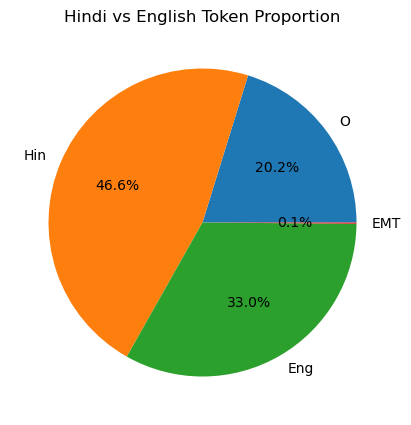

In [32]:
import matplotlib.pyplot as plt
plt.figure(figsize=(5,5))
plt.pie(
    lang_df["Count"],
    labels=lang_df["Language"],
    autopct="%1.1f%%"
    )
plt.title("Hindi vs English Token Proportion")

plt.savefig("../results/language_proportion.png")
plt.show()

In [36]:
df["sentiment"].value_counts()

sentiment
neutral     5638
positive    5034
negative    4459
Name: count, dtype: int64

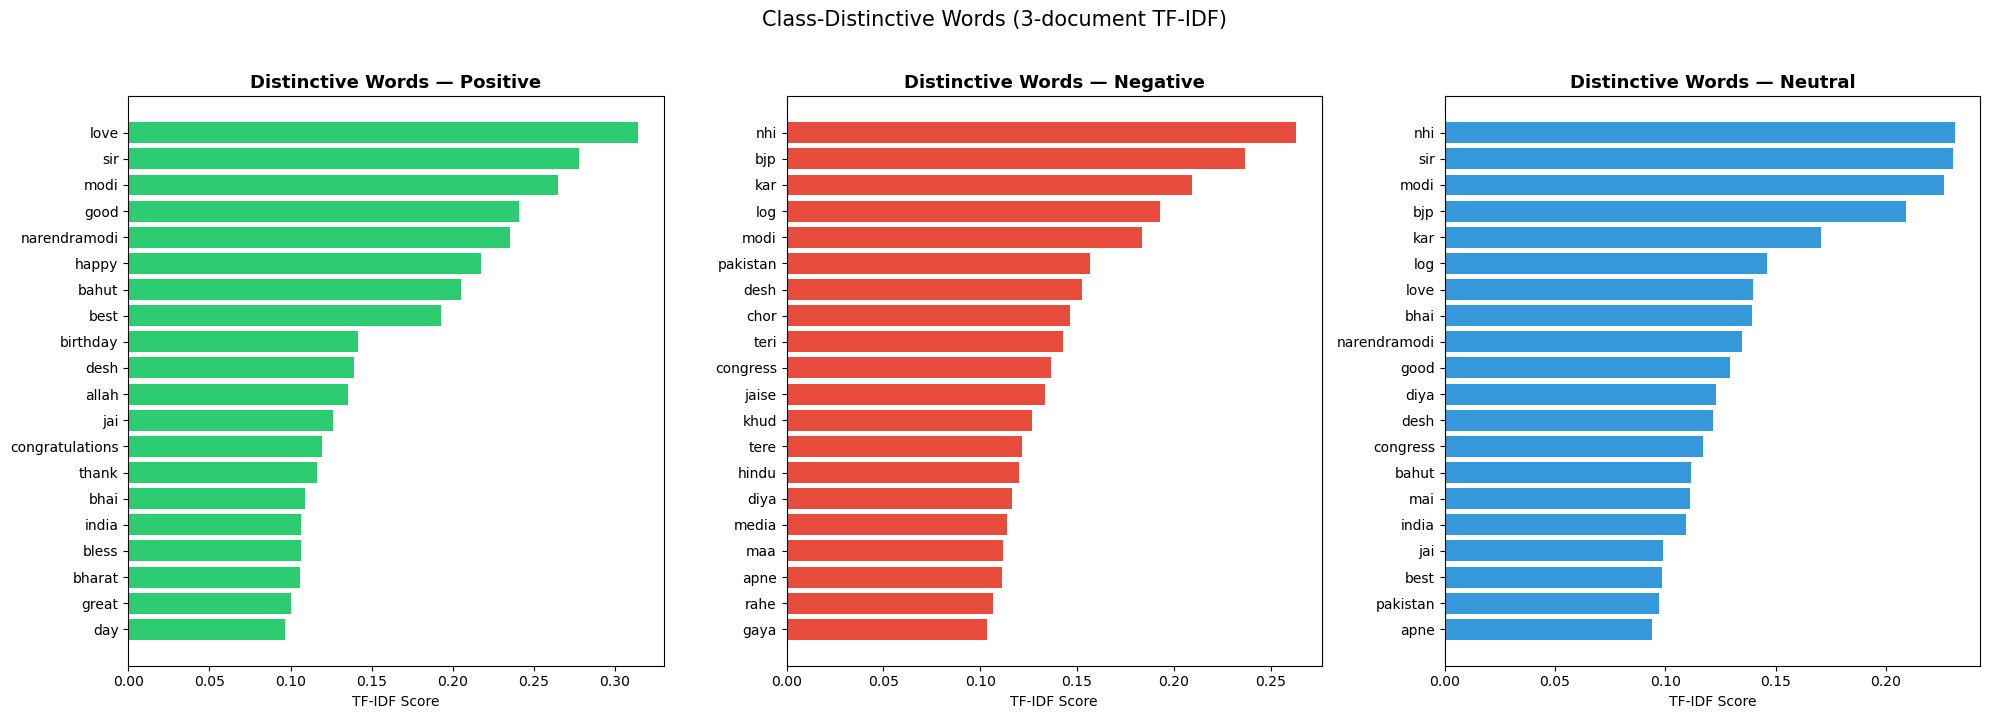

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.feature_extraction.text import TfidfVectorizer
import re

# ---- Clean function (Hindi + English stopwords) ----
HINDI_STOPS = {
    'hai', 'hain', 'ka', 'ki', 'ke', 'ko', 'me', 'se',
    'aur', 'bhi', 'nahi', 'koi', 'toh', 'yeh', 'wo',
    'kya', 'tha', 'thi', 'the', 'ek', 'ho', 'na', 'hi',
    'jo', 'ab', 'ye', 'woh', 'par', 'ne', 'mein', 'hoga',
    'raha', 'rahi', 'kuch', 'apna', 'apni', 'agar', 'bas',
    'mat', 'jab', 'tab', 'iss', 'us', 'unka', 'uska', 'hua',
    'hui', 'hue', 'tum', 'main', 'mujhe', 'aap', 'mere'
}

def clean(text):
    text = str(text).lower()
    text = re.sub(r'http\S+', '', text)      # URLs
    text = re.sub(r'@\w+', '', text)         # mentions
    text = re.sub(r'#\w+', '', text)         # hashtags
    text = re.sub(r'[^a-zA-Z\s]', '', text) # punctuation/numbers
    tokens = [t for t in text.split() 
              if t not in HINDI_STOPS and len(t) > 2]
    return ' '.join(tokens)

df['clean_text'] = df['text'].apply(clean)

# ---- Merge each class into one mega-document ----
classes = ['positive', 'negative', 'neutral']

class_docs = [
    ' '.join(df[df['sentiment'] == c]['clean_text'])
    for c in classes
]

# ---- Fit TF-IDF on 3 documents (one per class) ----
# Now IDF = low for words appearing in all 3 classes
vectorizer = TfidfVectorizer(
    max_features=5000,
    stop_words='english',   # catches remaining English stops
    min_df=1
)

tfidf_matrix = vectorizer.fit_transform(class_docs)
words = vectorizer.get_feature_names_out()

# ---- Plot for each class ----
fig, axes = plt.subplots(1, 3, figsize=(20, 7))

for i, (cls, ax) in enumerate(zip(classes, axes)):
    scores = np.asarray(tfidf_matrix[i].todense()).flatten()
    
    top_idx = scores.argsort()[::-1][:20]
    top_words = words[top_idx]
    top_scores = scores[top_idx]
    
    ax.barh(top_words[::-1], top_scores[::-1], color=['#2ecc71','#e74c3c','#3498db'][i])
    ax.set_title(f'Distinctive Words — {cls.capitalize()}', fontsize=13, fontweight='bold')
    ax.set_xlabel('TF-IDF Score')

plt.suptitle('Class-Distinctive Words (3-document TF-IDF)', fontsize=15, y=1.02)
plt.tight_layout()
plt.savefig('../results/top_tfidf_words_per_class.png', bbox_inches='tight', dpi=150)
plt.show()

In [69]:
with open("../data/hinglish_train.txt", "r", encoding="utf-8") as f:
    for _ in range(30):
        print(f.readline().rstrip())

meta	3	negative
@	O
AdilNisarButt	Hin
pakistan	Hin
ka	Hin
ghra	Hin
tauq	Hin
he	Eng
Pakistan	Eng
Israel	Eng
ko	Eng
tasleem	Hin
nahein	Hin
kerta	Hin
Isko	Hin
Palestine	Hin
kehta	Hin
he	Hin
-	O
OCCUPIED	Hin
PALESTINE	Hin

meta	41	negative
Madarchod	Hin
mulle	Hin
ye	Hin
mathura	Hin
me	Hin
Nahi	Hin
dikha	Hin


In [70]:
with open('../data/hinglish_train.txt', 'r') as f:
    for line in f.readlines()[:5]:
        print(repr(line))

'meta\t3\tnegative\n'
'@\tO\n'
'AdilNisarButt\tHin\n'
'pakistan\tHin\n'
'ka\tHin\n'


In [ ]:
#the data already has language tage, lets extract that into a df
def parse_hinglish_file(filepath):
    tweets = []
    current_tokens = []
    current_langs = []
    current_meta = None
    
    with open(filepath, 'r') as f:
        for line in f:
            line = line.strip()
            parts = line.split('\t')
            
            if parts[0] == 'meta':
                # Save previous tweet
                if current_meta:
                    current_meta['tokens'] = current_tokens
                    current_meta['token_langs'] = current_langs
                    current_meta['text'] = ' '.join(current_tokens)
                    current_meta['hindi_ratio'] = (
                        current_langs.count('Hin') / len(current_langs) 
                        if current_langs else 0.0
                    )
                    tweets.append(current_meta)
                
                # Start new tweet
                current_meta = {
                    'tweet_id': parts[1],
                    'sentiment': parts[2]
                }
                current_tokens = []
                current_langs = []
            
            elif len(parts) == 2:
                current_tokens.append(parts[0])
                current_langs.append(parts[1])
        
        # Don't forget last tweet
        if current_meta:
            current_meta['tokens'] = current_tokens
            current_meta['token_langs'] = current_langs
            current_meta['text'] = ' '.join(current_tokens)
            current_meta['hindi_ratio'] = (
                current_langs.count('Hin') / len(current_langs) 
                if current_langs else 0.0
            )
            tweets.append(current_meta)
    
    return pd.DataFrame(tweets)

df_train = parse_hinglish_file('../data/hinglish_train.txt')
df_train.head(3)

,tweet_id,sentiment,tokens,token_langs,text,hindi_ratio
0,3,negative,"[@, AdilNisarButt, pakistan, ka, ghra, tauq, h...","[O, Hin, Hin, Hin, Hin, Hin, Eng, Eng, Eng, En...",@ AdilNisarButt pakistan ka ghra tauq he Pakis...,0.70000
1,41,negative,"[Madarchod, mulle, ye, mathura, me, Nahi, dikh...","[Hin, Hin, Hin, Hin, Hin, Hin, Hin, Hin, Hin, ...",Madarchod mulle ye mathura me Nahi dikha tha j...,0.71875
2,48,positive,"[@, narendramodi, Manya, Pradhan, Mantri, maho...","[O, Hin, Hin, Hin, Hin, Hin, Hin, Hin, Hin, Hi...",@ narendramodi Manya Pradhan Mantri mahoday Sh...,0.64000


In [72]:
print(df_train.columns)
print(df_train[['text', 'token_langs', 'hindi_ratio', 'sentiment']].head(5))
print(df_train['token_langs'].iloc[0])  # should show list of Hin/En/O tags


Index(['tweet_id', 'sentiment', 'tokens', 'token_langs', 'text',
       'hindi_ratio'],
      dtype='object')
                                                text  \
0  @ AdilNisarButt pakistan ka ghra tauq he Pakis...   
1  Madarchod mulle ye mathura me Nahi dikha tha j...   
2  @ narendramodi Manya Pradhan Mantri mahoday Sh...   
3  @ Atheist _ Krishna Jcb full trend me chal rah...   
4  @ AbhisharSharma _ @ RavishKumarBlog Loksabha ...   

                                         token_langs  hindi_ratio sentiment  
0  [O, Hin, Hin, Hin, Hin, Hin, Eng, Eng, Eng, En...     0.700000  negative  
1  [Hin, Hin, Hin, Hin, Hin, Hin, Hin, Hin, Hin, ...     0.718750  negative  
2  [O, Hin, Hin, Hin, Hin, Hin, Hin, Hin, Hin, Hi...     0.640000  positive  
3  [O, Eng, O, Eng, Eng, Eng, Eng, Eng, Hin, Hin,...     0.272727  positive  
4  [O, Hin, O, O, Hin, Eng, Hin, Hin, Hin, Hin, H...     0.468750  positive  
['O', 'Hin', 'Hin', 'Hin', 'Hin', 'Hin', 'Eng', 'Eng', 'Eng', 'Eng', 'Hin', 'Hin', 'H

In [74]:
# flatten all tags and get unique values
all_tags = [tag for tags in df_train['token_langs'] for tag in tags]
print(set(all_tags))

{'Eng', 'Hin', 'EMT', 'O'}


In [75]:
#computing hingi and english ratios 
def compute_ratios(token_langs):
    if not token_langs:
        return 0.0, 0.0
    total = len(token_langs)
    hindi = token_langs.count('Hin')
    eng = token_langs.count('Eng')
    return hindi / total, eng / total

df_train[['hindi_ratio', 'eng_ratio']] = df_train['token_langs'].apply(
    lambda tags: pd.Series(compute_ratios(tags))
)

# quick sanity check
df_train[['text', 'hindi_ratio', 'eng_ratio', 'sentiment']].head(5)

,text,hindi_ratio,eng_ratio,sentiment
0,@ AdilNisarButt pakistan ka ghra tauq he Pakis...,0.700000,0.200000,negative
1,Madarchod mulle ye mathura me Nahi dikha tha j...,0.718750,0.156250,negative
2,@ narendramodi Manya Pradhan Mantri mahoday Sh...,0.640000,0.160000,positive
3,@ Atheist _ Krishna Jcb full trend me chal rah...,0.272727,0.545455,positive
4,@ AbhisharSharma _ @ RavishKumarBlog Loksabha ...,0.468750,0.312500,positive


In [76]:
from collections import Counter

all_tags = [tag for tags in df_train['token_langs'] for tag in tags]
print(Counter(all_tags))

Counter({'Hin': 184546, 'Eng': 130827, 'O': 80069, 'EMT': 543})


In [78]:
#calculate switch count 
def count_switches(token_langs):
    # only count switches between Hin and Eng, ignore O and emt
    filtered = [t for t in token_langs if t in ('Hin', 'Eng')]
    if len(filtered) < 2:
        return 0
    switches = sum(1 for i in range(1, len(filtered)) 
                   if filtered[i] != filtered[i-1])
    return switches

df_train['switch_count'] = df_train['token_langs'].apply(count_switches)

# check distribution per sentiment class
df_train.groupby('sentiment')['switch_count'].mean()

sentiment
negative    3.472079
neutral     3.516140
positive    3.486889
Name: switch_count, dtype: float64

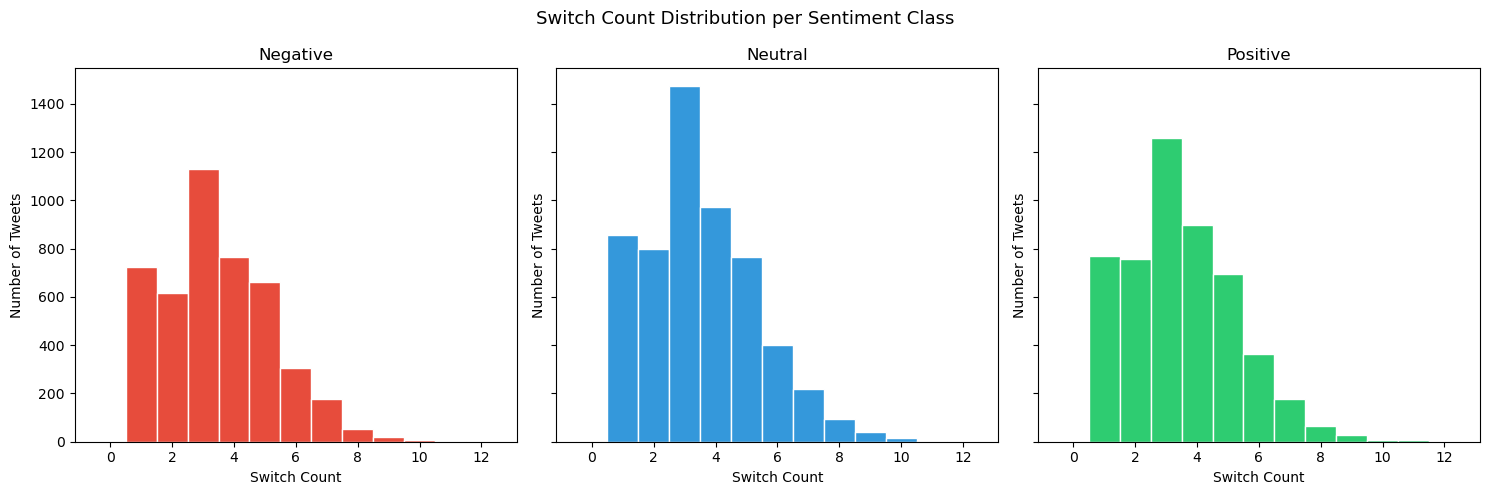

In [83]:
import numpy as np

max_switches = int(df_train['switch_count'].max())
bins = np.arange(0, max_switches + 2, 1)  # [0, 1, 2, 3, ... max+1]

fig, axes = plt.subplots(1, 3, figsize=(15, 5), sharey=True)

for ax, (sentiment, group) in zip(axes, df_train.groupby('sentiment')):
    ax.hist(group['switch_count'], bins=bins, 
            color={'positive':'#2ecc71', 
                   'negative':'#e74c3c', 
                   'neutral':'#3498db'}[sentiment],
            edgecolor='white', align='left')
    ax.set_title(f'{sentiment.capitalize()}')
    ax.set_xlabel('Switch Count')
    ax.set_ylabel('Number of Tweets')
    ax.set_xticks(range(0, max_switches + 1, 2))

plt.suptitle('Switch Count Distribution per Sentiment Class', fontsize=13)
plt.tight_layout()
plt.savefig('../results/switch_count_distribution.png', bbox_inches='tight', dpi=150)
plt.show()

In [84]:
print(df_train.groupby('sentiment')['switch_count'].agg(['mean', 'median', 'std']))


               mean  median       std
sentiment                            
negative   3.472079     3.0  1.780790
neutral    3.516140     3.0  1.818344
positive   3.486889     3.0  1.795840
